## Project Idea: Scalable Google Play Store App Review Analysis & Categorization Pipeline
Overview: Build an end-to-end ML system to:

Classify app reviews as positive/negative/neutral (sentiment classification).

Cluster similar reviews into topics (e.g., "battery drain", "bugs", "UI issues") using unsupervised learning.

Combine them to generate insights like "Top complaint categories for low-rated apps" or "Which features users love most".

# Data Preprocessing

In [1]:
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
import pandas as pd

df = pd.read_csv('/content/reviews.csv')
# df.head()

In [3]:
df = df.loc[:, ['content', 'score']]
df.head()

,content,score
0,I cannot open the app anymore,1
1,I have been begging for a refund from this app...,1
2,Very costly for the premium version (approx In...,1
3,"Used to keep me organized, but all the 2020 UP...",1
4,Dan Birthday Oct 28,1


In [4]:
df.shape

(12495, 2)

In [5]:
df.isnull().sum()

,0
content,0
score,0


In [6]:
df['score'].unique()

array([1, 2, 3, 4, 5])

In [7]:
score_two_df = df[df['score'] == 2]

In [8]:
import numpy as np

conditions = [
    df['score'] <= 2,
    df['score'] == 3,
    df['score'] >= 4
]

choices = ['Negative', 'Neutral', 'Positive']

df['sentiment'] = np.select(conditions, choices, default='Unknown')

df.head()

,content,score,sentiment
0,I cannot open the app anymore,1,Negative
1,I have been begging for a refund from this app...,1,Negative
2,Very costly for the premium version (approx In...,1,Negative
3,"Used to keep me organized, but all the 2020 UP...",1,Negative
4,Dan Birthday Oct 28,1,Negative


In [9]:
df.drop('score', axis=1, inplace=True)
df.head()

,content,sentiment
0,I cannot open the app anymore,Negative
1,I have been begging for a refund from this app...,Negative
2,Very costly for the premium version (approx In...,Negative
3,"Used to keep me organized, but all the 2020 UP...",Negative
4,Dan Birthday Oct 28,Negative


# Classify APP Review

In [10]:
import re
def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", "", text)           # Remove HTML tags
    text = re.sub(r"http\S+|www\S+", "", text)  # Remove URLs
    text = re.sub(r"\s+", " ", text)            # Remove extra spaces
    text = text.strip()
    return text

df["content"] = df["content"].apply(clean_text)

In [11]:
df.head()

,content,sentiment
0,I cannot open the app anymore,Negative
1,I have been begging for a refund from this app...,Negative
2,Very costly for the premium version (approx In...,Negative
3,"Used to keep me organized, but all the 2020 UP...",Negative
4,Dan Birthday Oct 28,Negative


In [12]:
def sentiment_into_number(sentiment):
  if sentiment == 'Negative':
    return 0
  elif sentiment == 'Neutral':
    return 1
  elif sentiment == 'Positive':
    return 2

df['sentiment'] = df['sentiment'].apply(sentiment_into_number)

In [13]:
df['sentiment'].value_counts()

,count
sentiment,
2,5654
0,4850
1,1991


In [14]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.1,          # 10% goes to test (~1,246 rows)
    random_state=42,
    stratify=df["sentiment"]    # Keep class balance
)

In [15]:
print(f"\nTrain size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")


Train size: 11245
Test size:  1250


## FineTune LLM

In [16]:
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)

from datasets import Dataset

In [17]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["content"],
        padding="max_length",   # Pad short texts with [PAD] tokens
        truncation=True,        # Cut texts longer than max_length
        max_length=128          # 128 tokens is enough for most reviews
    )

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [18]:
train_dataset = Dataset.from_pandas(train_df[['content', 'sentiment']].rename(columns={'sentiment': 'labels'}).reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df[['content', 'sentiment']].rename(columns={'sentiment': 'labels'}).reset_index(drop=True))

In [19]:
# Apply tokenizer to every row
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/11245 [00:00<?, ? examples/s]

Map:   0%|          | 0/1250 [00:00<?, ? examples/s]

In [20]:
# Tell HuggingFace these columns are PyTorch tensors
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch",  columns=["input_ids", "attention_mask", "labels"])

In [21]:
train_dataset[0]

{'labels': tensor(1),
 'input_ids': tensor([  101,  5942,  2326,  1000,  8094,  5527,  1000,  1010,  2023,  2001,
          4895,  7076,  9080,  3709,  2013,  2026,  5080,  1998,  2061,  2023,
         10439,  2097,  2025,  2147,  1012,  1052,  1012,  1055,  1012,  1045,
          2106,  2424,  2019, 10439,  1061, 12707,  2987,  1005,  1056,  5478,
          1000, 21854, 11563,  5527,  1000,  1012,  2036,  2904,  2000,  1017,
         14117,  2015,  2004,  1045,  2435,  1996, 10439,  1015,  2732,  2011,
          6707,  1010,  1019,  5369,  2047,  3556,  2003,  2273,  2102,  2000,
          2022,  8699,   102,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,  

In [22]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

model.config.id2label = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

model.config.label2id = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [23]:
training_args = TrainingArguments(
    output_dir="./sentiment_model",       # Where to save model checkpoints

    # --- Training settings ---
    num_train_epochs=4,                   # Pass through training data 4 times
    per_device_train_batch_size=16,       # 16 samples per training step
    per_device_eval_batch_size=32,        # 32 samples per evaluation step

    # --- Learning rate ---
    learning_rate=2e-5,                   # Standard for BERT fine-tuning
    weight_decay=0.01,                    # Helps prevent overfitting

    # --- No validation → evaluate only at the end ---
    eval_strategy="no",            # Don't evaluate during training
    save_strategy="epoch",               # Still save after each epoch
    load_best_model_at_end=False,        # Can't load best without eval

    # --- Logging ---
    logging_dir="./logs",
    logging_steps=50,                    # Print loss every 50 steps

    seed=42,
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [24]:
print("\nStarting training...")
trainer.train()


Starting training...


Step,Training Loss
50,0.923891
100,0.747469
150,0.675792
200,0.640414
250,0.662558
300,0.668260
350,0.630739
400,0.619965
450,0.586831
500,0.634845


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2812, training_loss=0.4882427035151301, metrics={'train_runtime': 510.7982, 'train_samples_per_second': 88.058, 'train_steps_per_second': 5.505, 'total_flos': 1489622462714880.0, 'train_loss': 0.4882427035151301, 'epoch': 4.0})

In [25]:
print("\n=== Test Set Evaluation ===")

# Run the model on test data and collect predictions
predictions_output = trainer.predict(test_dataset)

# Convert raw model scores (logits) → predicted class index
predicted_labels = np.argmax(predictions_output.predictions, axis=-1)
true_labels  = predictions_output.label_ids


=== Test Set Evaluation ===


In [26]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Detailed report: Precision, Recall, F1 for each class
print("\nClassification Report:")
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=["Negative", "Neutral", "Positive"]
))

# Confusion matrix: see exactly where the model gets confused
print("Confusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

# Overall numbers
overall_acc = accuracy_score(true_labels, predicted_labels)
overall_f1  = f1_score(true_labels, predicted_labels, average="weighted")
print(f"\nOverall Accuracy: {overall_acc:.4f}")
print(f"Overall F1 Score: {overall_f1:.4f}")



Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.78      0.79       485
     Neutral       0.36      0.32      0.34       199
    Positive       0.83      0.89      0.86       566

    accuracy                           0.75      1250
   macro avg       0.66      0.66      0.66      1250
weighted avg       0.75      0.75      0.75      1250

Confusion Matrix:
[[377  66  42]
 [ 74  63  62]
 [ 17  46 503]]

Overall Accuracy: 0.7544
Overall F1 Score: 0.7489


In [27]:
model.save_pretrained("./final_sentiment_model")
tokenizer.save_pretrained("./final_sentiment_model")
print("\nModel saved to ./final_sentiment_model")


from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="./final_sentiment_model",
    tokenizer="./final_sentiment_model"
)

test_reviews = [
    "This product is absolutely amazing, I love it!",
    "It's okay, nothing special about it.",
    "Terrible experience, completely broke after one day."
]

print("\n=== Live Predictions ===")
for review in test_reviews:
    result = classifier(review)[0]
    print(f"Review:    {review}")
    print(f"Sentiment: {result['label']} (confidence: {result['score']:.2%})\n")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to ./final_sentiment_model


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== Live Predictions ===
Review:    This product is absolutely amazing, I love it!
Sentiment: Positive (confidence: 98.95%)

Review:    It's okay, nothing special about it.
Sentiment: Negative (confidence: 71.74%)

Review:    Terrible experience, completely broke after one day.
Sentiment: Negative (confidence: 97.79%)



## Apply the Random Forest Using TFIDF

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['content'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['content'])

print("Shape of X_train_tfidf:", X_train_tfidf.shape)
print("Shape of X_test_tfidf:", X_test_tfidf.shape)

Shape of X_train_tfidf: (11245, 11687)
Shape of X_test_tfidf: (1250, 11687)


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(random_state=42)

# Train the model
rf_classifier.fit(X_train_tfidf, train_df['sentiment'])

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


In [30]:
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test_tfidf)

# Evaluate the model
print("\nRandomForestClassifier - Classification Report:")
print(classification_report(
    test_df['sentiment'],
    y_pred_rf,
    target_names=model.config.id2label.values()
))

print("\nRandomForestClassifier - Confusion Matrix:")
print(confusion_matrix(test_df['sentiment'], y_pred_rf))


RandomForestClassifier - Classification Report:
              precision    recall  f1-score   support

    Negative       0.68      0.82      0.74       485
     Neutral       0.40      0.01      0.02       199
    Positive       0.75      0.86      0.80       566

    accuracy                           0.71      1250
   macro avg       0.61      0.57      0.52      1250
weighted avg       0.66      0.71      0.65      1250


RandomForestClassifier - Confusion Matrix:
[[400   2  83]
 [115   2  82]
 [ 76   1 489]]


## Train Logistic Regression with TF-IDF



In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Instantiate Logistic Regression model
lr_classifier = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
lr_classifier.fit(X_train_tfidf, train_df['sentiment'])

print("LogisticRegression model trained successfully.")

# Make predictions on the test set
y_pred_lr = lr_classifier.predict(X_test_tfidf)

# Evaluate the model
print("\nLogisticRegression - Classification Report:")
print(classification_report(
    test_df['sentiment'],
    y_pred_lr,
    target_names=model.config.id2label.values()
))

print("\nLogisticRegression - Confusion Matrix:")
print(confusion_matrix(test_df['sentiment'], y_pred_lr))

LogisticRegression model trained successfully.

LogisticRegression - Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.82      0.77       485
     Neutral       0.44      0.12      0.19       199
    Positive       0.77      0.88      0.82       566

    accuracy                           0.74      1250
   macro avg       0.65      0.61      0.59      1250
weighted avg       0.70      0.74      0.70      1250


LogisticRegression - Confusion Matrix:
[[398  16  71]
 [ 95  24  80]
 [ 52  14 500]]


## Train Support Vector Machine (SVM) with TF-IDF


In [32]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Instantiate SVC model
# Using a linear kernel explicitly for better performance on sparse data like TF-IDF, or use LinearSVC
svm_classifier = SVC(kernel='linear', random_state=42, max_iter=1000) # Increased max_iter for convergence

# Train the model
print("Training SVM classifier...")
svm_classifier.fit(X_train_tfidf, train_df['sentiment'])
print("SVM classifier trained successfully.")

# Make predictions on the test set
y_pred_svm = svm_classifier.predict(X_test_tfidf)

# Evaluate the model
print("\nSupport Vector Machine - Classification Report:")
print(classification_report(
    test_df['sentiment'],
    y_pred_svm,
    target_names=model.config.id2label.values()
))

print("\nSupport Vector Machine - Confusion Matrix:")
print(confusion_matrix(test_df['sentiment'], y_pred_svm))

Training SVM classifier...
SVM classifier trained successfully.

Support Vector Machine - Classification Report:
              precision    recall  f1-score   support

    Negative       0.71      0.72      0.72       485
     Neutral       0.30      0.27      0.28       199
    Positive       0.80      0.82      0.81       566

    accuracy                           0.69      1250
   macro avg       0.60      0.60      0.60      1250
weighted avg       0.69      0.69      0.69      1250


Support Vector Machine - Confusion Matrix:
[[351  79  55]
 [ 82  53  64]
 [ 58  44 464]]


## Train XGBoost with TF-IDF


In [33]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Instantiate XGBoost model
xgb_classifier = XGBClassifier(random_state=42)

# Train the model
print("Training XGBoost classifier...")
xgb_classifier.fit(X_train_tfidf, train_df['sentiment'])
print("XGBoost classifier trained successfully.")

# Make predictions on the test set
y_pred_xgb = xgb_classifier.predict(X_test_tfidf)

# Evaluate the model
print("\nXGBoost Classifier - Classification Report:")
print(classification_report(
    test_df['sentiment'],
    y_pred_xgb,
    target_names=model.config.id2label.values()
))

print("\nXGBoost Classifier - Confusion Matrix:")
print(confusion_matrix(test_df['sentiment'], y_pred_xgb))

Training XGBoost classifier...
XGBoost classifier trained successfully.

XGBoost Classifier - Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.77      0.75       485
     Neutral       0.42      0.13      0.19       199
    Positive       0.75      0.89      0.81       566

    accuracy                           0.72      1250
   macro avg       0.63      0.60      0.59      1250
weighted avg       0.69      0.72      0.69      1250


XGBoost Classifier - Confusion Matrix:
[[374  21  90]
 [ 93  25  81]
 [ 47  13 506]]


# CLustering

In [35]:
!pip install keybert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.8 MB/s eta 0:00:00


In [38]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

from sentence_transformers import SentenceTransformer  # Converts text → vectors
import umap                                        # Reduces vector dimensions
import hdbscan                                         # Extracts keywords per cluster

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter

print("\nLoading embedding model...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding reviews (this may take a few minutes)...")
embeddings = embedder.encode(
    df["content"].tolist(),
    batch_size=64,         # Process 64 reviews at a time
    show_progress_bar=True
)

print(f"Embeddings shape: {embeddings.shape}")  # (12459, 384)

# ============================================================
# STEP 5: Reduce dimensions with UMAP
# ============================================================
# HDBSCAN struggles with 384-dimensional data (curse of dimensionality).
# UMAP compresses 384 dimensions → 10 dimensions while keeping structure.
# Think of it like zooming out on a map to see clusters more clearly.

print("\nReducing dimensions with UMAP...")
reducer = umap.UMAP(
    n_components=10,       # Reduce to 10 dimensions (good balance)
    n_neighbors=15,        # How many neighbors to consider (higher = bigger clusters)
    min_dist=0.0,          # Allow points to be close together (better for clustering)
    metric="cosine",       # Cosine similarity works best for text
    random_state=42
)
reduced_embeddings = reducer.fit_transform(embeddings)
print(f"Reduced shape: {reduced_embeddings.shape}")  # (12459, 10)

# ============================================================
# STEP 6: Cluster with HDBSCAN
# ============================================================
print("\nClustering with HDBSCAN...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,       # A topic needs at least 50 reviews
    min_samples=10,            # Core points need 10 nearby neighbors
    metric="euclidean",        # Distance measure on reduced embeddings
    cluster_selection_method="eom"  # 'eom' finds more varied cluster sizes
)
cluster_labels = clusterer.fit_predict(reduced_embeddings)

# -1 means "noise" — reviews that didn't fit any cluster
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise    = (cluster_labels == -1).sum()

print(f"Clusters found:  {n_clusters}")
print(f"Noise points:    {n_noise} ({n_noise/len(df)*100:.1f}%)")

df["cluster"] = cluster_labels

from keybert import KeyBERT

print("\nExtracting keywords to name clusters...")
kw_model = KeyBERT("all-MiniLM-L6-v2")

cluster_names = {}

for cluster_id in sorted(set(cluster_labels)):
    if cluster_id == -1:
        cluster_names[-1] = "Uncategorized"
        continue

    # Grab all reviews in this cluster
    cluster_reviews = df[df["cluster"] == cluster_id]["content"].tolist()

    # Combine into one big text block for keyword extraction
    combined_text = " ".join(cluster_reviews[:200])  # cap at 200 to stay fast

    # Extract top 3 keywords/keyphrases
    keywords = kw_model.extract_keywords(
        combined_text,
        keyphrase_ngram_range=(1, 2),  # 1-2 word phrases (e.g., "battery drain")
        stop_words="english",
        top_n=3,
        use_mmr=True,                  # MMR = picks diverse keywords, not repetitive
        diversity=0.5
    )

    # Join the top keywords into a readable topic name
    topic_name = " | ".join([kw[0] for kw in keywords])
    cluster_names[cluster_id] = topic_name
    print(f"  Cluster {cluster_id:2d} ({len(cluster_reviews):4d} reviews): {topic_name}")

df["topic"] = df["cluster"].map(cluster_names)


Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding reviews (this may take a few minutes)...


Batches:   0%|          | 0/196 [00:00<?, ?it/s]

Embeddings shape: (12495, 384)

Reducing dimensions with UMAP...
Reduced shape: (12495, 10)

Clustering with HDBSCAN...
Clusters found:  46
Noise points:    4166 (33.3%)

Extracting keywords to name clusters...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Cluster  0 ( 158 reviews): improv good | good goodd | yes
  Cluster  1 (  54 reviews): nice nice | nice neat | neat
  Cluster  2 ( 239 reviews): forest app | better premium | staying task
  Cluster  3 (  86 reviews): app gd | good working | connects desktop
  Cluster  4 ( 222 reviews): ninja cerebral | pomdoro bad | awesome looooooooooooooooove
  Cluster  5 (  91 reviews): bad enjoying | outstanding performance | far pretty
  Cluster  6 (  62 reviews): beautiful amazing | efficient thank | line
  Cluster  7 (  89 reviews): tarefas que | tasks somem | app parfaite
  Cluster  8 ( 205 reviews): hai best | payment use | apo 4k
  Cluster  9 (  62 reviews): worst app | mining rubbish | unhelpful unmotivating
  Cluster 10 ( 998 reviews): reminders annoying | phone vibrates | app pay
  Cluster 11 ( 130 reviews): todo apps | decent widget | list ticktick
  Cluster 12 ( 167 reviews): planner apps | smallest widget | definitely best
  Cluster 13 ( 320 reviews): syncs alexa | app hanging | broke

In [39]:
df.head()

,content,sentiment,cluster,topic
0,I cannot open the app anymore,0,25,app crashed | samsung tablet | 2020 updates
1,I have been begging for a refund from this app...,0,20,app subscription | premium error | refund months
2,Very costly for the premium version (approx In...,0,-1,Uncategorized
3,"Used to keep me organized, but all the 2020 UP...",0,25,app crashed | samsung tablet | 2020 updates
4,Dan Birthday Oct 28,0,-1,Uncategorized


In [40]:
topics = df['topic'].unique()

In [41]:
topics

array(['app crashed | samsung tablet | 2020 updates',
       'app subscription | premium error | refund months',
       'Uncategorized', 'apps lists | retap grocery | viewed different',
       'reminders annoying | phone vibrates | app pay',
       'worst app | mining rubbish | unhelpful unmotivating',
       'syncs alexa | app hanging | broken backup',
       'ads popups | coins doubled | app disabling',
       'tasks widget | lists prioritized | search feature',
       'calendar app | sync useless | button dipak',
       'todo apps | decent widget | list ticktick',
       'hai best | payment use | apo 4k',
       'recommend simple | usefull application | design complex',
       'using free | features locked | upgrade pay',
       'account app | skip login | force uninstalled',
       'improv good | good goodd | yes',
       'tasks delete | app buggy | someday sorting',
       'worth using | customers feedback | years customisable',
       'discarded usefull | making useful | tool gre

In [42]:
!pip install langchain_groq
!pip install langchain_core
!pip install langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.3 MB/s eta 0:00:00


In [44]:
from google.colab import userdata
key = userdata.get('groq')

In [45]:
import os
os.environ["GROQ_API_KEY"] = key

In [46]:
import pandas as pd
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Assuming 'df' is your existing DataFrame and 'topics' is defined
# topics = df['topic'].unique()

clean_topics_name = {}

# 1. Initialize the LLM
llm = ChatGroq(model_name="llama-3.1-8b-instant")

# 2. Define an optimized prompt
# We add instructions to ensure the LLM only outputs the short topic name, preventing chatty responses.
prompt_text = """
Analyze the following keywords and generate a short, concise topic name (1 to 5 words max) that summarizes them.
Return ONLY the topic name. Do not include any introductory text, quotes, or punctuation.

Keywords: {words}
"""
prompt = PromptTemplate.from_template(prompt_text)

# 3. Create the chain using LCEL
chain = prompt | llm | StrOutputParser()

# 4. Loop through unique topics and generate clean names
print("Generating clean topic names...")
for x in topics:
    try:
        response = chain.invoke({"words": x})
        clean_topics_name[x] = response.strip()
        print(f"Mapped: '{x[:20]}...' -> '{clean_topics_name[x]}'")
    except Exception as e:
        print(f"Error processing {x}: {e}")
        clean_topics_name[x] = "Unknown Topic"

# 5. Apply the dictionary back to the DataFrame
# .map() will look at every value in df['topic'], find it in the dictionary keys,
# and replace it with the dictionary value.
df['clean_topic'] = df['topic'].map(clean_topics_name)

print("Mapping complete! Here is a preview of your DataFrame:")

Generating clean topic names...
Mapped: 'app crashed | samsun...' -> 'Samsung Tablet 2020 Crashes'
Mapped: 'app subscription | p...' -> 'App Subscription Issues'
Mapped: 'Uncategorized...' -> 'General Information'
Mapped: 'apps lists | retap g...' -> 'Grocery Shopping App Lists'
Mapped: 'reminders annoying |...' -> 'Intrusive Mobile Payment Reminders'
Mapped: 'worst app | mining r...' -> 'Poor Mobile Application Experience'
Mapped: 'syncs alexa | app ha...' -> 'Alexa Sync Issues'
Mapped: 'ads popups | coins d...' -> 'Mobile Ad Blocking'
Mapped: 'tasks widget | lists...' -> 'Task Management Tool'
Mapped: 'calendar app | sync ...' -> 'Calendar App Glitches'
Mapped: 'todo apps | decent w...' -> 'Comparison of Todo Apps'
Mapped: 'hai best | payment u...' -> 'High Definition Video Payments'
Mapped: 'recommend simple | u...' -> 'Designing Complex Apps'
Mapped: 'using free | feature...' -> 'Free Software Limitations'
Mapped: 'account app | skip l...' -> 'Account Uninstallation App'
Mapped: 'i

In [47]:
df_cluster_12 = df[df['cluster'] == 12]
display(df_cluster_12.head())

,content,sentiment,cluster,topic,clean_topic
770,Truly the best planning app! I was looking for...,2,12,planner apps | smallest widget | definitely best,Best Small Planner Apps
1519,It's a gr8 app. Very useful for daily planners...,2,12,planner apps | smallest widget | definitely best,Best Small Planner Apps
1582,420/420 amazing app that beats my lame ass pla...,2,12,planner apps | smallest widget | definitely best,Best Small Planner Apps
2013,"Awful support, unable to move re-occuring task...",0,12,planner apps | smallest widget | definitely best,Best Small Planner Apps
2173,Didnt like that to really use it as a planner ...,0,12,planner apps | smallest widget | definitely best,Best Small Planner Apps


In [48]:
df.to_csv('reviews_with_topics.csv', index=False)
print("DataFrame saved to reviews_with_topics.csv")

DataFrame saved to reviews_with_topics.csv


In [49]:
df.drop('topic', axis=1, inplace=True)
df.rename(columns={'clean_topic': 'topic'}, inplace=True)
df.head()

,content,sentiment,cluster,topic
0,I cannot open the app anymore,0,25,Samsung Tablet 2020 Crashes
1,I have been begging for a refund from this app...,0,20,App Subscription Issues
2,Very costly for the premium version (approx In...,0,-1,General Information
3,"Used to keep me organized, but all the 2020 UP...",0,25,Samsung Tablet 2020 Crashes
4,Dan Birthday Oct 28,0,-1,General Information


# Insights


INSIGHT 1: TOP COMPLAINT TOPICS (Negative Reviews)
                             topic  review_count  percentage
Intrusive Mobile Payment Reminders           542        11.2
             Calendar App Glitches           309         6.4
        Account Uninstallation App           253         5.2
           App Subscription Issues           236         4.9
       Samsung Tablet 2020 Crashes           229         4.7
                 Alexa Sync Issues           211         4.4
            Forest Task Management           142         2.9
            Designing Complex Apps           123         2.5
                Mobile Ad Blocking           116         2.4
         Task Management Overviews            93         1.9

INSIGHT 2: WHAT USERS LOVE MOST (Positive Reviews)
                             topic  review_count  percentage
                 Useful Phone Apps           402         7.1
             Calendar App Glitches           252         4.5
               Habit Tracking Apps        

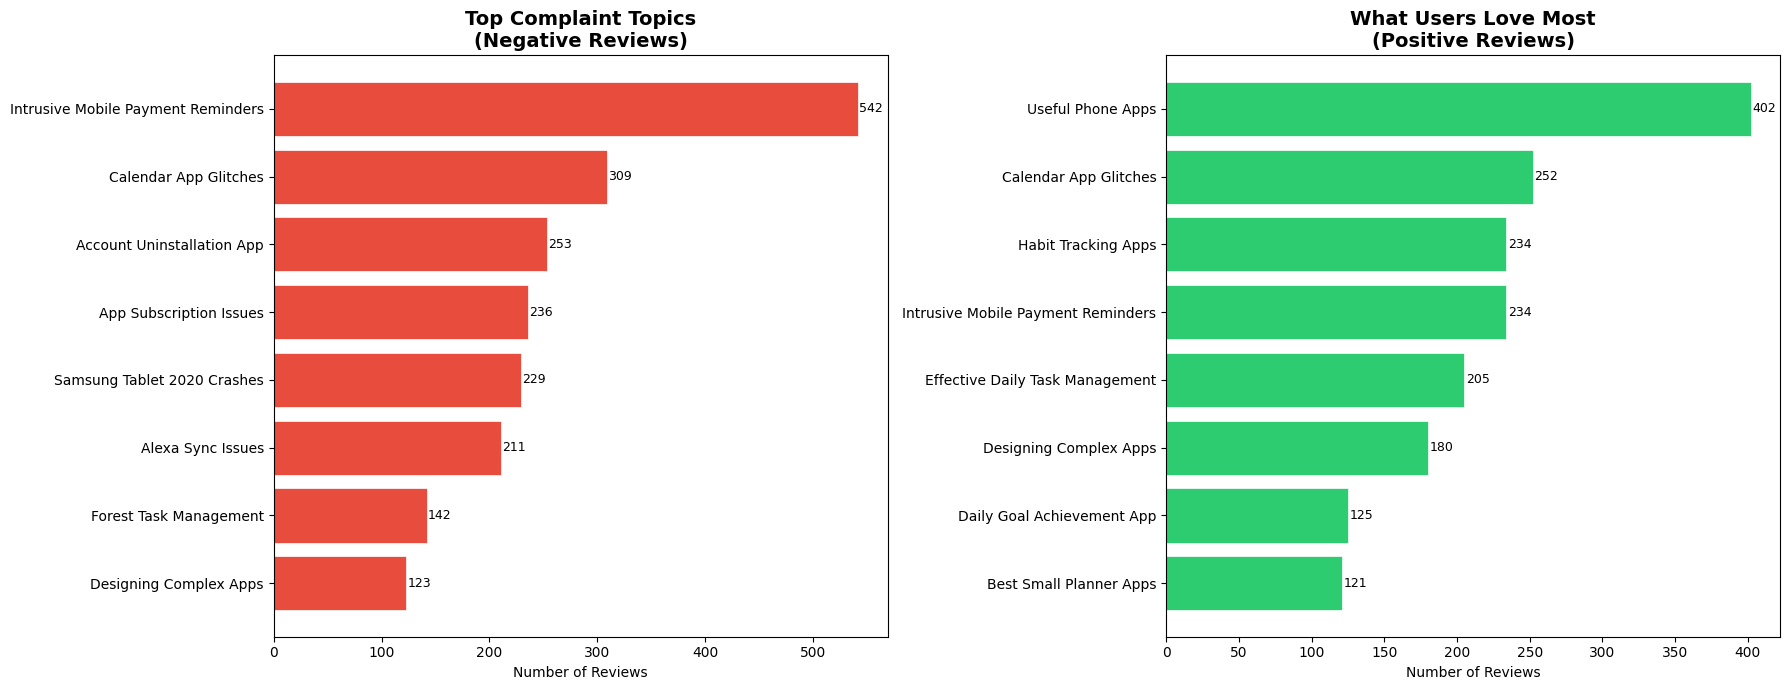

Saved: insight_bar_charts.png


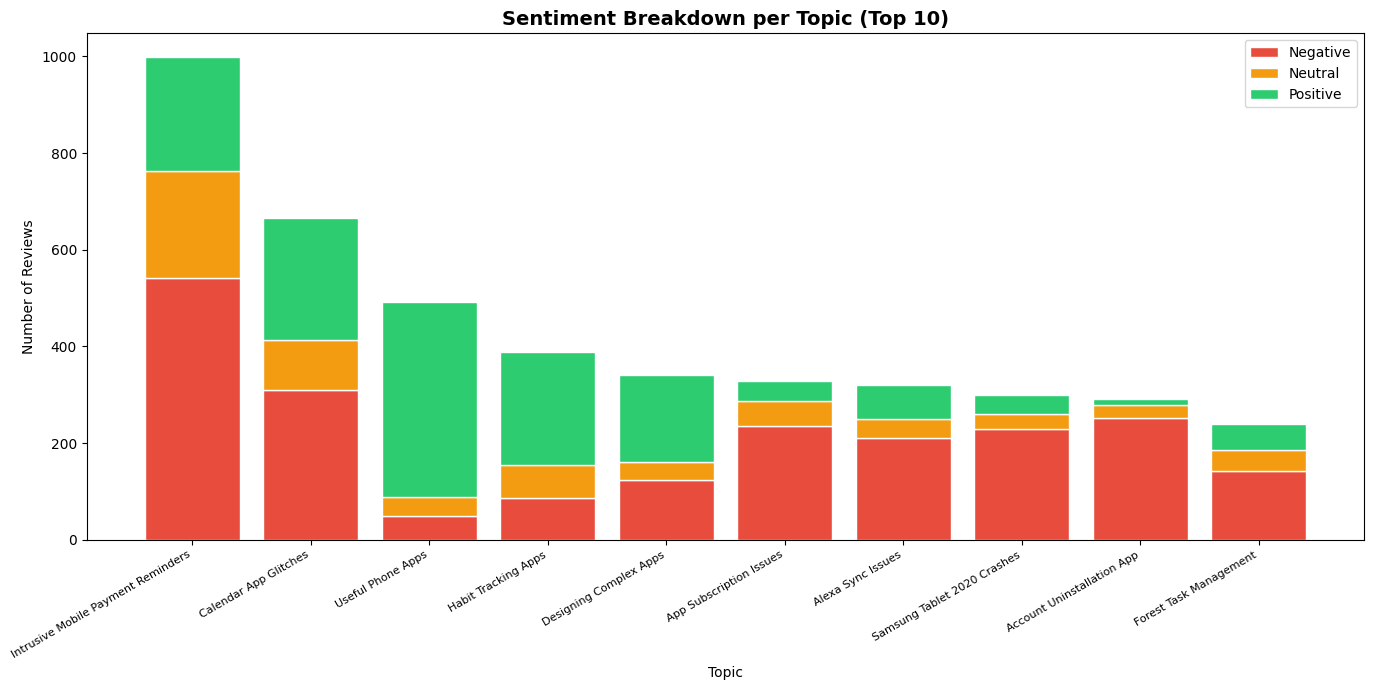

Saved: sentiment_per_topic.png

Generating 2D cluster visualization...


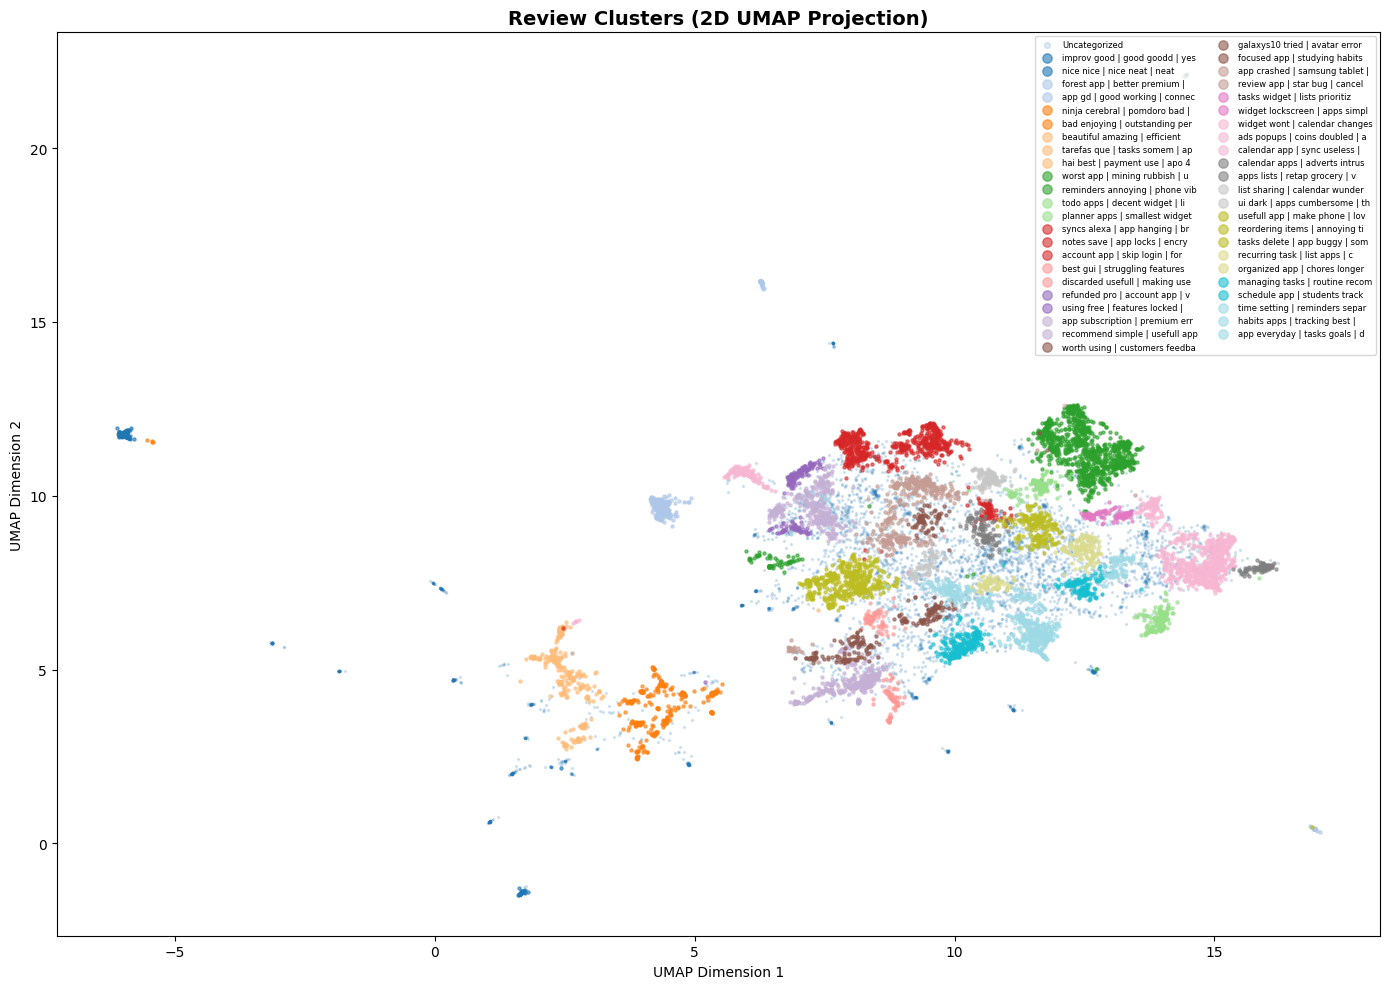

Saved: cluster_scatter.png

Full results saved to: reviews_with_topics.csv

FINAL SUMMARY REPORT
Total reviews analyzed:     12,495
Topics discovered:          46
Uncategorized (noise):      4166 (33.3%)

Sentiment distribution:
  Positive  : 5,654 (45.3%)
  Negative  : 4,850 (38.8%)
  Neutral   : 1,991 (15.9%)

Top 3 complaint topics:
  • Intrusive Mobile Payment Reminders                 → 542 negative reviews
  • Calendar App Glitches                              → 309 negative reviews
  • Account Uninstallation App                         → 253 negative reviews

Top 3 praised topics:
  • Useful Phone Apps                                  → 402 positive reviews
  • Calendar App Glitches                              → 252 positive reviews
  • Habit Tracking Apps                                → 234 positive reviews


In [51]:
# ============================================================
# STEP 8: INSIGHTS — Top complaint categories for low-rated apps
# ============================================================
print("\n" + "="*60)
print("INSIGHT 1: TOP COMPLAINT TOPICS (Negative Reviews)")
print("="*60)

# Corrected: Filter using numerical sentiment value (0 for Negative)
negative_df = df[df["sentiment"] == 0]

# Count how many negative reviews fall in each topic
complaint_counts = (
    negative_df[negative_df["cluster"] != -1]  # Exclude noise
    .groupby("topic")
    .size()
    .reset_index(name="review_count")
    .sort_values("review_count", ascending=False)
)

# Add percentage column
# Check if negative_df is not empty before calculating percentage
if not negative_df.empty:
    complaint_counts["percentage"] = (
        complaint_counts["review_count"] / len(negative_df) * 100
    ).round(1)
else:
    complaint_counts["percentage"] = 0 # Handle empty case if needed
    print("No negative reviews found in non-noise clusters.") # Add a message for clarity

print(complaint_counts.head(10).to_string(index=False))

# ============================================================
# STEP 9: INSIGHTS — Features users love most (Positive reviews)
# ============================================================
print("\n" + "="*60)
print("INSIGHT 2: WHAT USERS LOVE MOST (Positive Reviews)")
print("="*60)

# Corrected: Filter using numerical sentiment value (2 for Positive)
positive_df = df[df["sentiment"] == 2]

praise_counts = (
    positive_df[positive_df["cluster"] != -1]
    .groupby("topic")
    .size()
    .reset_index(name="review_count")
    .sort_values("review_count", ascending=False)
)

# Add percentage column
# Check if positive_df is not empty before calculating percentage
if not positive_df.empty:
    praise_counts["percentage"] = (
        praise_counts["review_count"] / len(positive_df) * 100
    ).round(1)
else:
    praise_counts["percentage"] = 0 # Handle empty case if needed
    print("No positive reviews found in non-noise clusters.") # Add a message for clarity

print(praise_counts.head(10).to_string(index=False))

# ============================================================
# STEP 10: INSIGHTS — Sentiment breakdown per topic
# ============================================================
print("\n" + "="*60)
print("INSIGHT 3: SENTIMENT BREAKDOWN PER TOPIC")
print("="*60)

# Cross-tabulate: for each topic, how many Negative/Neutral/Positive reviews?
df_for_sentiment_breakdown = df[df["cluster"] != -1].copy()
# Map numerical sentiment to string labels for correct column names
df_for_sentiment_breakdown["sentiment_label"] = df_for_sentiment_breakdown["sentiment"].map(model.config.id2label)

topic_sentiment = (
    df_for_sentiment_breakdown
    .groupby(["topic", "sentiment_label"])
    .size()
    .unstack(fill_value=0)  # Make sentiment columns (Negative, Neutral, Positive)
    .reset_index()
)

# Ensure all three sentiment columns exist, filling with 0 if any are missing
for sentiment_name in ["Negative", "Neutral", "Positive"]:
    if sentiment_name not in topic_sentiment.columns:
        topic_sentiment[sentiment_name] = 0

# Add total and dominant sentiment
topic_sentiment["total"] = topic_sentiment[["Negative", "Neutral", "Positive"]].sum(axis=1)
topic_sentiment["dominant_sentiment"] = topic_sentiment[["Negative", "Neutral", "Positive"]].idxmax(axis=1)
topic_sentiment = topic_sentiment.sort_values("total", ascending=False)

print(topic_sentiment.to_string(index=False))

# ============================================================
# STEP 11: INSIGHTS — Most polarizing topics
# ============================================================
print("\n" + "="*60)
print("INSIGHT 4: MOST POLARIZING TOPICS (mixed sentiment)")
print("="*60)

# Polarizing = topics with BOTH high negative AND high positive reviews
filtered = topic_sentiment[topic_sentiment["total"] >= 50].copy()
filtered["neg_ratio"] = filtered["Negative"] / filtered["total"]
filtered["pos_ratio"] = filtered["Positive"] / filtered["total"]

# Polarizing score = how evenly split is the topic between neg and pos
filtered["polarizing_score"] = 1 - abs(filtered["neg_ratio"] - filtered["pos_ratio"])
polarizing = filtered.sort_values("polarizing_score", ascending=False)

print(polarizing[["topic", "Negative", "Positive", "total", "polarizing_score"]].head(8).to_string(index=False))

# ============================================================
# STEP 12: VISUALIZATIONS
# ============================================================

# --- Chart 1: Top Complaint Topics (bar chart) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_complaints = complaint_counts.head(8)
axes[0].barh(
    top_complaints["topic"][::-1],
    top_complaints["review_count"][::-1],
    color="#e74c3c", edgecolor="white", linewidth=0.5
)
axes[0].set_title("Top Complaint Topics\n(Negative Reviews)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Number of Reviews")
for i, v in enumerate(top_complaints["review_count"][::-1]):
    axes[0].text(v + 1, i, str(v), va="center", fontsize=9)

# --- Chart 2: What Users Love (bar chart) ---
top_praise = praise_counts.head(8)
axes[1].barh(
    top_praise["topic"][::-1],
    top_praise["review_count"][::-1],
    color="#2ecc71", edgecolor="white", linewidth=0.5
)
axes[1].set_title("What Users Love Most\n(Positive Reviews)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Number of Reviews")
for i, v in enumerate(top_praise["review_count"][::-1]):
    axes[1].text(v + 1, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("insight_bar_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: insight_bar_charts.png")

# --- Chart 3: Stacked bar — sentiment per topic ---
# Ensure top_topics is not empty before attempting to plot
if not topic_sentiment.empty:
    top_topics = topic_sentiment.head(10).set_index("topic")
    colors     = {"Negative": "#e74c3c", "Neutral": "#f39c12", "Positive": "#2ecc71"}

    fig, ax = plt.subplots(figsize=(14, 7))
    bottom = np.zeros(len(top_topics))
    for sentiment in ["Negative", "Neutral", "Positive"]:
        if sentiment in top_topics.columns: # Check if sentiment column exists
            ax.bar(
                top_topics.index,
                top_topics[sentiment],
                bottom=bottom,
                label=sentiment,
                color=colors[sentiment],
                edgecolor="white"
            )
            bottom += top_topics[sentiment].values

    ax.set_title("Sentiment Breakdown per Topic (Top 10)", fontsize=14, fontweight="bold")
    ax.set_xlabel("Topic")
    ax.set_ylabel("Number of Reviews")
    ax.legend()
    plt.xticks(rotation=30, ha="right", fontsize=8)
    plt.tight_layout()
    plt.savefig("sentiment_per_topic.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: sentiment_per_topic.png")
else:
    print("Skipping 'Sentiment Breakdown per Topic' chart: topic_sentiment DataFrame is empty.")


# --- Chart 4: 2D UMAP scatter plot of clusters ---
print("\nGenerating 2D cluster visualization...")
reducer_2d = umap.UMAP(
    n_components=2, n_neighbors=15,
    min_dist=0.1, metric="cosine", random_state=42
)
embedding_2d = reducer_2d.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(14, 10))
unique_clusters = sorted(set(cluster_labels))
colors_map = cm.get_cmap("tab20", len(unique_clusters))

for i, cid in enumerate(unique_clusters):
    mask = cluster_labels == cid
    label = cluster_names.get(cid, f"Cluster {cid}")
    alpha = 0.15 if cid == -1 else 0.6
    size  = 2    if cid == -1 else 5
    ax.scatter(
        embedding_2d[mask, 0],
        embedding_2d[mask, 1],
        c=[colors_map(i)],
        label=label[:30],      # Truncate long names
        alpha=alpha,
        s=size
    )

ax.set_title("Review Clusters (2D UMAP Projection)", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=6, markerscale=3, ncol=2)
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")
plt.tight_layout()
plt.savefig("cluster_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cluster_scatter.png")

# ============================================================
# STEP 13: Export full results to CSV
# ============================================================
# Corrected: Removed 'score' as it was dropped earlier
output_df = df[["content", "sentiment", "cluster", "topic"]].copy()
output_df.to_csv("reviews_with_topics.csv", index=False)
print("\nFull results saved to: reviews_with_topics.csv")

# ============================================================
# STEP 14: Final Summary Report
# ============================================================
print("\n" + "="*60)
print("FINAL SUMMARY REPORT")
print("="*60)
print(f"Total reviews analyzed:     {len(df):,}")
print(f"Topics discovered:          {n_clusters}")
print(f"Uncategorized (noise):      {n_noise} ({n_noise/len(df)*100:.1f}%)")
print(f"\nSentiment distribution:")
# Ensure sentiment value counts are mapped to labels for the final report
sentiment_counts = df["sentiment"].map(model.config.id2label).value_counts()
for s, count in sentiment_counts.items():
    print(f"  {s:<10}: {count:,} ({count/len(df)*100:.1f}%)")

print(f"\nTop 3 complaint topics:")
if not complaint_counts.empty:
    for _, row in complaint_counts.head(3).iterrows():
        print(f"  • {row['topic'][:50]:<50} → {row['review_count']} negative reviews")
else:
    print("  No top complaint topics to display.")

print(f"\nTop 3 praised topics:")
if not praise_counts.empty:
    for _, row in praise_counts.head(3).iterrows():
        print(f"  • {row['topic'][:50]:<50} → {row['review_count']} positive reviews")
else:
    print("  No top praised topics to display.")